In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Make plots show inline in the notebook
%matplotlib inline

## Load an airport-year file

In [9]:
df = pd.read_csv("../data_clean/KDAL_2019_clean.csv", parse_dates=["datetime"])
df.head(100)

,datetime,airport,station,lat,lon,elev_m,wind_dir_deg,wind_speed_ms,vis_m,ceiling_m,ceiling_unlimited,temp_c,dewpoint_c,slp_hpa,precip_mm_1h,precip_mm_6h,precip_mm_24h
0,2019-01-01 00:00:00+00:00,KDAL,72258013960,32.8519,-96.8555,134.1,NaN,9,16093.0,9144.0,False,11.7,5.0,1013.7,0.0,NaN,NaN
1,2019-01-01 01:00:00+00:00,KDAL,72258013960,32.8519,-96.8555,134.1,320.0,5,16093.0,NaN,False,9.4,5.0,1014.6,0.0,NaN,NaN
2,2019-01-01 02:00:00+00:00,KDAL,72258013960,32.8519,-96.8555,134.1,320.0,5,16093.0,NaN,False,8.9,3.3,1015.4,0.0,NaN,NaN
3,2019-01-01 03:00:00+00:00,KDAL,72258013960,32.8519,-96.8555,134.1,340.0,5,16093.0,NaN,False,8.9,2.8,1015.8,0.0,NaN,NaN
4,2019-01-01 04:00:00+00:00,KDAL,72258013960,32.8519,-96.8555,134.1,340.0,5,16093.0,NaN,False,7.2,2.8,1017.3,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2019-01-04 23:00:00+00:00,KDAL,72258013960,32.8519,-96.8555,134.1,NaN,9,16093.0,NaN,False,13.3,-1.1,1016.0,0.0,NaN,NaN
96,2019-01-05 00:00:00+00:00,KDAL,72258013960,32.8519,-96.8555,134.1,60.0,5,16093.0,NaN,False,8.9,2.2,1016.6,0.0,NaN,NaN
97,2019-01-05 01:00:00+00:00,KDAL,72258013960,32.8519,-96.8555,134.1,NaN,9,16093.0,NaN,False,7.8,2.8,1017.1,0.0,NaN,NaN
98,2019-01-05 02:00:00+00:00,KDAL,72258013960,32.8519,-96.8555,134.1,NaN,9,16093.0,NaN,False,7.2,2.2,1017.5,0.0,NaN,NaN


## Create the wind_stress function

In [10]:
def wind_stress(wind_speed_ms):
    """
    Convert wind speed (m/s) into a 0–100 'wind stress' score.
    0   = calm/weak winds (<= 10 kt)
    100 = very strong winds (>= 35 kt)
    Linear ramp between 10 and 35 kt.
    """
    if pd.isna(wind_speed_ms):
        return np.nan
    
    # m/s -> knots
    knots = wind_speed_ms * 1.94384
    
    if knots <= 10:
        return 0.0
    elif knots >= 35:
        return 100.0
    else:
        return (knots - 10) / (35 - 10) * 100.0

In [11]:
# Load the new cleaned data (no manual scaling!)
df = pd.read_csv("../data_clean/KDAL_2019_clean.csv", parse_dates=["datetime"])

df["wind_stress"] = df["wind_speed_ms"].apply(wind_stress)
df[["wind_speed_ms", "wind_stress"]].describe()

,wind_speed_ms,wind_stress
count,8760.000000,8760.000000
mean,5.584475,4.548069
std,1.474969,10.755062
min,1.000000,0.000000
25%,5.000000,0.000000
50%,5.000000,0.000000
75%,5.000000,0.000000
max,9.000000,29.978240


In [12]:
df["wind_stress"].describe()

count    8760.000000
mean        4.548069
std        10.755062
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        29.978240
Name: wind_stress, dtype: float64

In [13]:
df.nlargest(10, "wind_speed_ms")[["datetime", "wind_speed_ms"]]


,datetime,wind_speed_ms
0,2019-01-01 00:00:00+00:00,9
5,2019-01-01 05:00:00+00:00,9
29,2019-01-02 05:00:00+00:00,9
53,2019-01-03 05:00:00+00:00,9
61,2019-01-03 13:00:00+00:00,9
77,2019-01-04 05:00:00+00:00,9
95,2019-01-04 23:00:00+00:00,9
97,2019-01-05 01:00:00+00:00,9
98,2019-01-05 02:00:00+00:00,9
99,2019-01-05 03:00:00+00:00,9


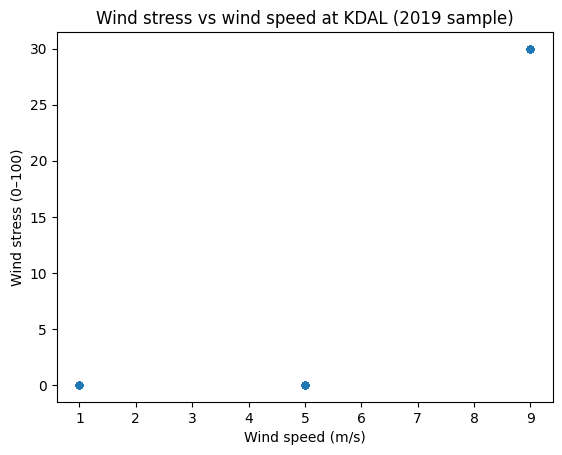

In [14]:
# Drop NaNs just in case
tmp = df[["wind_speed_ms", "wind_stress"]].dropna()

tmp.plot.scatter(x="wind_speed_ms", y="wind_stress", alpha=0.3)
plt.xlabel("Wind speed (m/s)")
plt.ylabel("Wind stress (0–100)")
plt.title("Wind stress vs wind speed at KDAL (2019 sample)")
plt.show()

## Visibility stress Logic

In [15]:
def visibility_stress(vis_m):
    """
    Convert visibility (meters) into a 0–100 'visibility stress' score.
    0   = good visibility (>= 10 statute miles ~ 16,000 m)
    100 = very low visibility (<= 400 m)
    Linear ramp between 16,000 m and 400 m.
    """
    if pd.isna(vis_m):
        return np.nan

    # Cap extremely large values just in case
    if vis_m >= 16000:
        return 0.0
    elif vis_m <= 400:
        return 100.0
    else:
        # As vis decreases, stress increases
        return 100.0 * (16000 - vis_m) / (16000 - 400)

In [16]:
df["visibility_stress"] = df["vis_m"].apply(visibility_stress)

df[["datetime", "vis_m", "visibility_stress"]].head(10)
df["visibility_stress"].describe()

count    8394.000000
mean        5.370124
std        16.928080
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       100.000000
Name: visibility_stress, dtype: float64

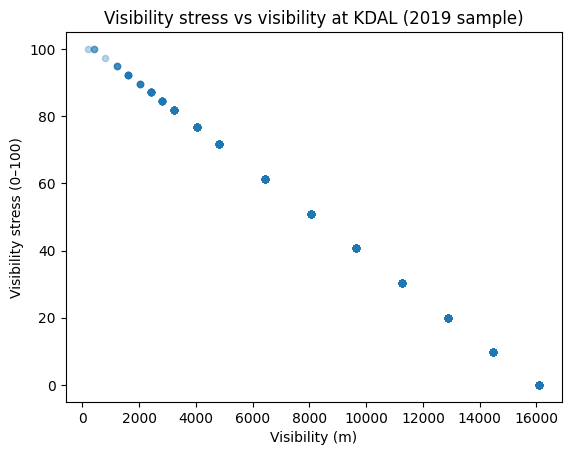

In [17]:
tmp = df[["vis_m", "visibility_stress"]].dropna()

tmp.plot.scatter(x="vis_m", y="visibility_stress", alpha=0.3)
plt.xlabel("Visibility (m)")
plt.ylabel("Visibility stress (0–100)")
plt.title("Visibility stress vs visibility at KDAL (2019 sample)")
plt.show()

In [18]:
df["visibility_stress"].describe()


count    8394.000000
mean        5.370124
std        16.928080
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       100.000000
Name: visibility_stress, dtype: float64

## Ceiling stress

In [19]:
def ceiling_stress_row(row):
    """
    Compute ceiling stress (0–100) from ceiling_m and ceiling_unlimited.

    0   = ceiling >= 3000 ft (~914 m) or unlimited
    100 = ceiling <= 200 ft (~60 m)
    Linear ramp between 60 m and 914 m.
    """
    h = row["ceiling_m"]
    unlimited = row["ceiling_unlimited"]

    # Unlimited ceiling → no stress
    if bool(unlimited):
        return 0.0

    # Missing ceiling (and not flagged unlimited) → unknown
    if pd.isna(h):
        return np.nan

    # Apply thresholds
    if h >= 914:         # >= 3000 ft
        return 0.0
    elif h <= 60:        # <= 200 ft
        return 100.0
    else:
        # As ceiling decreases, stress increases
        return 100.0 * (914 - h) / (914 - 60)

In [20]:
df["ceiling_stress"] = df.apply(ceiling_stress_row, axis=1)

df[["datetime", "ceiling_m", "ceiling_unlimited", "ceiling_stress"]].head(10)
df["ceiling_stress"].describe()

count    4683.000000
mean       17.479012
std        29.716195
min         0.000000
25%         0.000000
50%         0.000000
75%        28.454333
max        99.882904
Name: ceiling_stress, dtype: float64

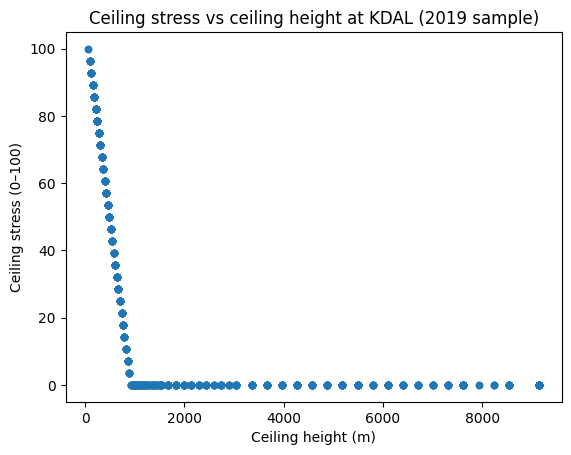

In [21]:
tmp = df[["ceiling_m", "ceiling_stress"]].dropna()

tmp.plot.scatter(x="ceiling_m", y="ceiling_stress", alpha=0.3)
plt.xlabel("Ceiling height (m)")
plt.ylabel("Ceiling stress (0–100)")
plt.title("Ceiling stress vs ceiling height at KDAL (2019 sample)")
plt.show()

## Temperatures Stress

In [22]:
def temperature_stress(temp_c: float) -> float:
    """
    Temperature stress for airline ops (0–100).

    - Comfortable band: 5°C to 30°C  → 0 stress
    - Cold side: from 5°C down to -15°C, stress rises 0 → 100
    - Hot side: from 30°C up to 45°C, stress rises 0 → 100
    - ≤ -15°C or ≥ 45°C → capped at 100
    """
    if pd.isna(temp_c):
        return np.nan

    # ---- Cold side ----
    if temp_c <= -15:
        return 100.0
    elif temp_c < 5:  # -15 < temp_c < 5
        # 5°C -> 0, -15°C -> 100
        return 100.0 * (5 - temp_c) / 20.0

    # ---- Hot side ----
    elif temp_c >= 45:
        return 100.0
    elif temp_c > 30:  # 30 < temp_c < 45
        # 30°C -> 0, 45°C -> 100
        return 100.0 * (temp_c - 30) / 15.0

    # ---- Comfortable band ----
    else:  # 5°C <= temp_c <= 30°C
        return 0.0

In [23]:
df["temperature_stress"] = df["temp_c"].apply(temperature_stress)

df[["datetime", "temp_c", "temperature_stress"]].head(10)
df["temperature_stress"].describe()

count    8388.000000
mean        4.910567
std        10.879277
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        62.666667
Name: temperature_stress, dtype: float64

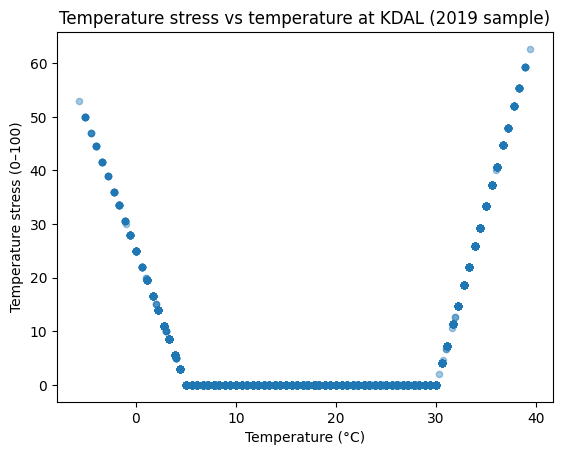

In [24]:
tmp = df[["temp_c", "temperature_stress"]].dropna()

tmp.plot.scatter(x="temp_c", y="temperature_stress", alpha=0.4)
plt.xlabel("Temperature (°C)")
plt.ylabel("Temperature stress (0–100)")
plt.title("Temperature stress vs temperature at KDAL (2019 sample)")
plt.show()


## Precipitation stress

In [25]:
def precipitation_stress(p_mm):
    """
    Convert 1-hour precipitation (mm) into a 0–100 'precipitation stress' score.
    - 0 mm/hr: no impact
    - 0–4 mm/hr: increasing stress
    - >=4 mm/hr: max stress (heavy precipitation)
    """
    if pd.isna(p_mm):
        return np.nan

    if p_mm >= 4:
        return 100.0
    elif p_mm <= 0:
        return 0.0
    else:
        return (p_mm / 4.0) * 100.0

In [26]:
df["precipitation_stress"] = df["precip_mm_1h"].apply(precipitation_stress)

df[["datetime", "precip_mm_1h", "precipitation_stress"]].head(10)
df["precipitation_stress"].describe()


count    7530.000000
mean        1.226096
std         9.053979
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       100.000000
Name: precipitation_stress, dtype: float64

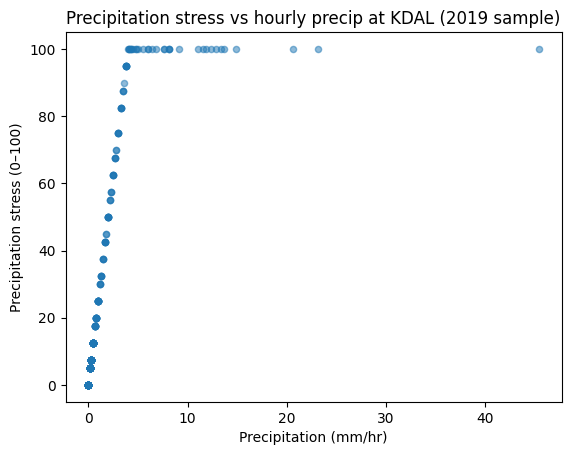

In [27]:
tmp = df[["precip_mm_1h", "precipitation_stress"]].dropna()

tmp.plot.scatter(x="precip_mm_1h", y="precipitation_stress", alpha=0.5)
plt.xlabel("Precipitation (mm/hr)")
plt.ylabel("Precipitation stress (0–100)")
plt.title("Precipitation stress vs hourly precip at KDAL (2019 sample)")
plt.show()

# Implement WIS for just KDAL 2019

In [28]:
df = pd.read_csv("../data_features/KDAL_2019_features.csv", parse_dates=["datetime"])

stress_cols = [
    "wind_stress",
    "visibility_stress",
    "ceiling_stress",
    "temperature_stress",
    "precipitation_stress",
]

df[stress_cols].head()

,wind_stress,visibility_stress,ceiling_stress,temperature_stress,precipitation_stress
0,29.97824,0.0,0.0,0.0,0.0
1,0.00000,0.0,NaN,0.0,0.0
2,0.00000,0.0,NaN,0.0,0.0
3,0.00000,0.0,NaN,0.0,0.0
4,0.00000,0.0,NaN,0.0,0.0


In [29]:
def compute_wis(row):
    # Equal weights for now (0.2 each)
    return (
        0.2 * row["wind_stress"] +
        0.2 * row["visibility_stress"] +
        0.2 * row["ceiling_stress"] +
        0.2 * row["temperature_stress"] +
        0.2 * row["precipitation_stress"]
    )

df["WIS"] = df.apply(compute_wis, axis=1)

df[["datetime", "WIS"] + stress_cols].head(10)
df["WIS"].describe()

count    3640.000000
mean        6.708877
std        10.621195
min         0.000000
25%         0.000000
50%         1.428571
75%         8.148912
max        60.929555
Name: WIS, dtype: float64

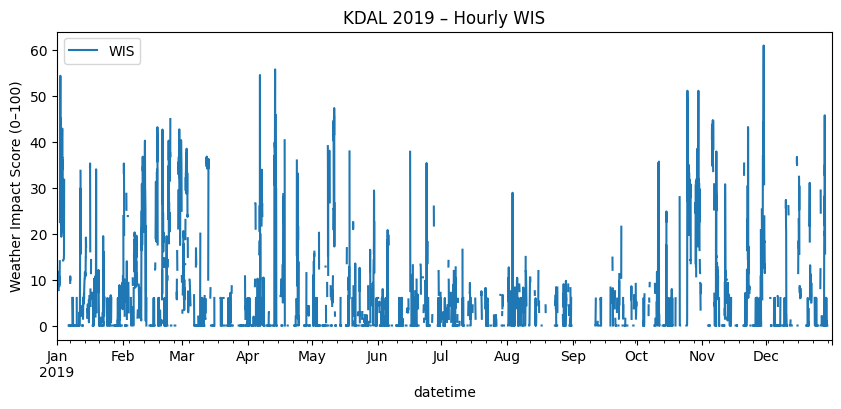

In [30]:
df.plot(x="datetime", y="WIS", figsize=(10,4))
plt.ylabel("Weather Impact Score (0–100)")
plt.title("KDAL 2019 – Hourly WIS")
plt.show()

### Comparing KDAL vs KDEN

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

df_dal = pd.read_csv("../data_features/KDAL_2019_features.csv", parse_dates=["datetime"])
df_den = pd.read_csv("../data_features/KDEN_2019_features.csv", parse_dates=["datetime"])

print("KDAL:", df_dal["WIS"].describe())
print("\nKDEN:", df_den["WIS"].describe())

KDAL: count    3640.000000
mean        6.708877
std        10.621195
min         0.000000
25%         0.000000
50%         1.428571
75%         8.148912
max        60.929555
Name: WIS, dtype: float64

KDEN: count    2528.000000
mean        8.460720
std        13.846161
min         0.000000
25%         0.000000
50%         1.100000
75%         8.951603
max        60.551899
Name: WIS, dtype: float64


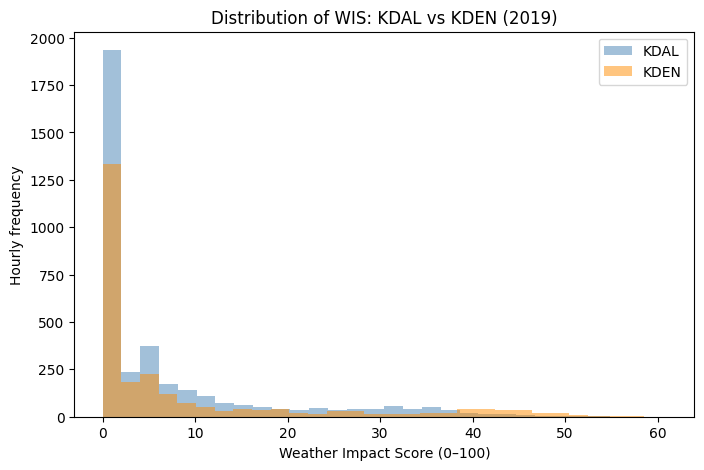

In [32]:
plt.figure(figsize=(8,5))
plt.hist(df_dal["WIS"], bins=30, alpha=0.5, label="KDAL", color="steelblue")
plt.hist(df_den["WIS"], bins=30, alpha=0.5, label="KDEN", color="darkorange")
plt.xlabel("Weather Impact Score (0–100)")
plt.ylabel("Hourly frequency")
plt.title("Distribution of WIS: KDAL vs KDEN (2019)")
plt.legend()
plt.show()

## Aggregation & Insights

Below creates summary metrics for each airport

In [33]:
import pandas as pd
import glob

files = glob.glob("../data_features/*_features.csv")

summary = []

for f in files:
    df = pd.read_csv(f, parse_dates=["datetime"])
    
    # 🧹 Filter out invalid "airport" entries (like 99999)
    df = df[df["airport"] != "99999"]
    if df.empty:
        continue  # Skip file if nothing left after filtering
    
    airport = df["airport"].iloc[0]
    
    summary.append({
        "airport": airport,
        "mean_WIS": df["WIS"].mean(skipna=True),
        "max_WIS": df["WIS"].max(),
        "p95_WIS": df["WIS"].quantile(0.95),
        "pct_above_20": (df["WIS"] > 20).mean() * 100,
    })

summary_df = pd.DataFrame(summary)
summary_df.sort_values("mean_WIS", ascending=False)


,airport,mean_WIS,max_WIS,p95_WIS,pct_above_20
42,KMDW,8.958653,55.550573,35.261940,9.422246
51,KOAK,8.492838,51.611917,23.841081,2.459300
18,KDEN,8.465125,60.551899,42.774017,6.129278
50,KOAK,8.413122,51.474566,23.757626,3.181142
6,KBWI,7.861543,61.542869,38.768510,6.943535
11,KBWI,7.774911,56.207338,35.965958,5.883254
49,KOAK,7.602861,45.995648,25.887020,3.564514
9,KBWI,7.505464,65.545445,36.694966,5.728143
43,KMDW,7.474613,53.268510,33.035824,6.591790
45,KMDW,7.383511,52.314493,32.359390,6.347600


In [34]:
summary_df = pd.DataFrame(summary)

airport_summary = (
    summary_df
      .groupby("airport")
      .agg(
          mean_WIS=("mean_WIS", "mean"),       # average across files for that airport
          max_WIS=("max_WIS", "max"),          # worst case across years/files
          p95_WIS=("p95_WIS", "mean"),         # average of per-file 95th percentiles
          pct_above_20=("pct_above_20", "mean") # average % of high-WIS hours
      )
      .reset_index()
      .sort_values("mean_WIS", ascending=False)
)

airport_summary

,airport,mean_WIS,max_WIS,p95_WIS,pct_above_20
8,KOAK,7.524739,55.215269,23.584357,2.820441
7,KMDW,7.293737,57.167284,32.685699,6.302817
1,KBWI,7.225897,65.545445,35.667195,5.706476
3,KDEN,6.784544,64.916874,39.784599,4.180383
4,KHOU,6.272416,60.929555,28.195218,3.946393
2,KDAL,6.218243,61.377894,29.911367,3.847816
0,KBNA,6.121388,63.719653,29.578199,3.733728
9,KPHX,3.674088,41.350776,14.681157,0.309686
6,KMCO,3.196875,55.897631,16.523004,1.320971
5,KLAS,2.968806,44.807716,11.540634,0.249691


<Axes: title={'center': 'Average WIS by Month at KDAL'}, xlabel='month'>

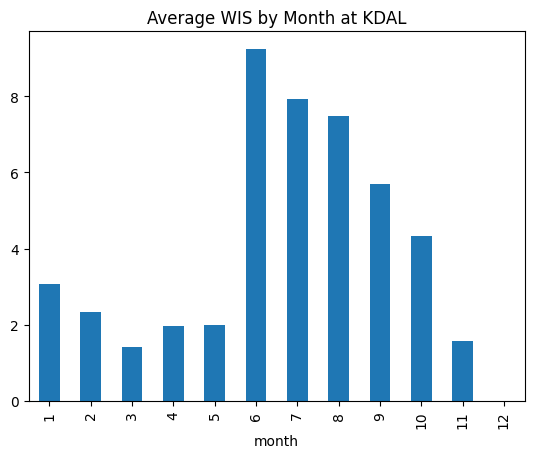

In [7]:
df["month"] = df["datetime"].dt.month
df.groupby("month")["WIS"].mean().plot(kind="bar", title="Average WIS by Month at KDAL")